<a href="https://colab.research.google.com/github/kyk-o/SecurityCamp/blob/main/%E3%82%BB%E3%82%AD%E3%83%A5%E3%83%AA%E3%83%86%E3%82%A3%E3%82%AD%E3%83%A3%E3%83%B3%E3%83%97_AIAgent%E8%AD%B0%E8%AB%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIエージェントに議論させる

In [1]:
# 1. リポジトリをコピー
!git clone https://github.com/elith-co-jp/book-llm-agent.git
# 2. フォルダの中身を確認
!ls

Cloning into 'book-llm-agent'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 218 (delta 34), reused 25 (delta 25), pack-reused 142 (from 1)
Receiving objects: 100% (218/218), 837.69 KiB | 4.50 MiB/s, done.
Resolving deltas: 100% (104/104), done.
book-llm-agent	drive  sample_data


In [2]:
# book-llm-agent フォルダに移動
%cd book-llm-agent

# 移動した後のフォルダ内にあるファイル一覧を表示
!ls

/content/book-llm-agent
llm_agent  notebooks  poetry.lock  pyproject.toml  README.md  tests


In [3]:
# フォルダ直下にある設定ファイルからインストールを試みる
!pip install .

Processing /content/book-llm-agent
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
# 1. フォルダに移動
%cd /content/book-llm-agent

# 2. notebooks フォルダの中身を確認
!ls notebooks

/content/book-llm-agent
chapter2  chapter3  chapter4


In [5]:
# chapter2 の中身を確認
!ls notebooks/chapter4

02_multi_agent_system_construction.ipynb
03_multi_agent_system_application.ipynb


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U langchain-community langchain langchain-openai

  Using cached langchain-1.3.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached langgraph-1.2.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached langgraph_checkpoint-4.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
Using cached langchain-1.3.0-py3-none-any.whl (114 kB)
Using cached langgraph-1.2.0-py3-none-any.whl (234 kB)
Using cached langgraph_checkpoint-4.1.0-py3-none-any.whl (56 kB)
Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl (41 kB)
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.0.2
    Uninstalling langgraph-checkpoint-4.0.2:
      Successfully uninstalled langgraph-checkpoint-4.0.2
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.0.10
    Uninstalling langgraph-prebuilt-1.0.10:
      Successfully uninstalled langgraph-prebuilt-1.0.10
  Attempting uninstall: langgraph
    Found existing installation: 

In [1]:
%cd /content/book-llm-agent

/content/book-llm-agent


In [ ]:
!pip install -e /content/book-llm-agent

Obtaining file:///content/book-llm-agent
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user
^C


In [2]:
import os
from google.colab import userdata

# OpenAI API キーの設定
# Colabのサイドバーにある鍵のアイコン（Secrets）をクリックし、
# 'OPENAI_API_KEY'という名前であなたのOpenAI APIキーを追加してください。
# その後、'Notebook access'をオンに設定してください。
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [3]:
import os
%cd /content/book-llm-agent

# Fix: Upgrade langchain-openai to resolve module not found error
!pip install -U langchain-openai

/content/book-llm-agent


In [4]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(model="gpt-4o", temperature=0, openai_api_key=os.environ.get("OPENAI_API_KEY"))

class State(TypedDict):
    count: int
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    messages = [llm.invoke(state["messages"])]
    count = state["count"] + 1
    return {
        "messages": messages,
        "count": count,
    }

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

In [5]:
# ペルソナの設定

from langchain_core.messages import SystemMessage
import os
from langchain_openai import ChatOpenAI

# Re-initialize llm to ensure it has the API key if this cell is run independently or out of order
llm = ChatOpenAI(model="gpt-4o", openai_api_key=os.environ.get("OPENAI_API_KEY"))

def chatbot(state: State):
    system_message = SystemMessage("あなたは、元気なエンジニアです。元気に返答してください。")
    messages = [llm.invoke([system_message] + state["messages"])]
    count = state["count"] + 1
    return {
        "messages": messages,
        "count": count,
    }

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import SystemMessagePromptTemplate
import functools
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(model="gpt-4o", openai_api_key=os.environ.get("OPENAI_API_KEY"))

def agent_with_persona(state: State, name: str, traits: str):
    system_message_template = SystemMessagePromptTemplate.from_template(
        "あなたの名前は{name}です。\nあなたの性格は以下のとおりです。\n\n{traits}"
    )
    system_message = system_message_template.format(name=name, traits=traits)

    message = HumanMessage(
        content=llm.invoke([system_message, *state["messages"]]).content,
        name=name,
    )

    return {
        "messages": [message],
    }

kenta_traits = """\
- アクティブで冒険好き\n- 新しい経験を求める\n- アウトドア活動を好む\n- SNSでの共有を楽しむ\n- エネルギッシュで社交的"""

mari_traits = """\
- 穏やかでリラックス志向\n- 家族を大切にする\n- 静かな趣味を楽しむ\n- 心身の休養を重視\n- 丁寧な生活を好む"""

yuta_traits = """\
- バランス重視\n- 柔軟性がある\n- 自己啓発に熱心\n- 伝統と現代の融合を好む\n- 多様な経験を求める"""

kenta = functools.partial(agent_with_persona, name="kenta", traits=kenta_traits)
mari = functools.partial(agent_with_persona, name="mari", traits=mari_traits)
yuta = functools.partial(agent_with_persona, name="yuta", traits=yuta_traits)

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
import os
from google.colab import userdata

class State(TypedDict):
    messages: Annotated[list, add_messages]

# Tavily APIキーの設定
# Colabのサイドバーにある鍵のアイコン（Secrets）をクリックし、
# 'TAVILY_API_KEY'という名前でTavily APIキーを追加してください。
# その後、'Notebook access'をオンに設定してください。
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')

#1 ツールの作成
tavily_tool = TavilySearchResults(max_results=2)

#2 ツールの紐づけ
llm = ChatOpenAI(model="gpt-4o", openai_api_key=os.environ.get("OPENAI_API_KEY"))
llm_with_tool = llm.bind_tools([tavily_tool])

#3 ツールを使ったチャットボットの作成
def chatbot(state: State):
    messages = [llm_with_tool.invoke(state["messages"])]
    return {
        "messages": messages,
    }

**以下、AIAgentによる議論（肯定側、否定側、ディベーターに分かれて議論させる）**

テーマ：AIの進化は人類にとって幸福か？


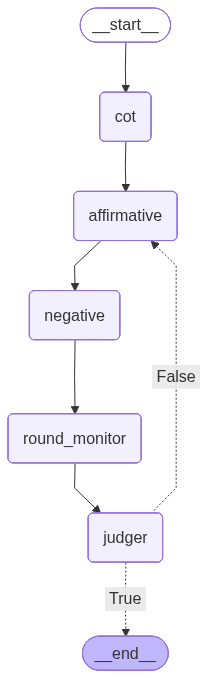

🎭 ディベート大会を開始します...

================================ Human Message =================================
Name: CoT_Assistant

議題「AIの進化は人類にとって幸福か？」について、以下のステップで論点を整理します。

### ステップ1: 定義の明確化
- **AIの進化**: 技術の進展によりAIがどのように進化しているか（機械学習、自然言語処理、ロボティクスなど）。
- **幸福**: 幸福の定義（個人の満足度、社会的な幸福、経済的な豊かさなど）。

### ステップ2: ポジティブな側面
1. **効率化と生産性向上**
   - AIによる業務の自動化と効率化。
   - 労働時間の短縮と新たな仕事の創出。

2. **生活の質の向上**
   - 医療分野でのAIの活用（診断精度の向上、個別化医療）。
   - 日常生活における便利なアプリケーション（スマートホーム、パーソナルアシスタント）。

3. **社会課題の解決**
   - 環境問題への対処（エネルギー管理、持続可能な開発）。
   - 教育の普及と質の向上（オンライン教育、個別指導）。

### ステップ3: ネガティブな側面
1. **雇用の喪失**
   - 自動化による職種の消失と再教育の必要性。
   - 経済的不平等の拡大。

2. **プライバシーとセキュリティの懸念**
   - データ収集とプライバシー侵害のリスク。
   - AIによる監視社会の懸念。

3. **倫理的な問題**
   - AIの判断における偏見や不公平。
   - 自律型兵器やAIによる決定の倫理的問題。

### ステップ4: 社会的・経済的影響
- **経済構造の変化**: AIがもたらす新しいビジネスモデルや市場の変化。
- **社会的な受容**: AIに対する社会の態度や文化的な影響。

### ステップ5: 長期的な視点
- **人類とAIの共生**: AIとの共存や協力の可能性。
- **未来のビジョン**: AIがもたらす未来の社会像とその幸福度。

### ステップ6: 結論の形成
- ポジティブな側面とネガティブな側面を総合的に評価し、AIの進化が人類にとって幸福かどうかの結

In [11]:
import os
import functools
from typing import Annotated, TypedDict
from google.colab import userdata
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import display, Image

# 1. APIキーの設定
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. モデルの準備 (審判は賢い4o、選手は機敏な4o-mini)
llm_judge = ChatOpenAI(model="gpt-4o", temperature=0)
llm_player = ChatOpenAI(model="gpt-4o-mini", temperature=0.7) # 議論を活性化させるため少し温度を上げます

# 3. 状態(State)の定義
class DebateState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    debate_topic: str
    judged: bool
    round: int

# --- 4. エージェント関数の定義 ---

# 導入エージェント (CoT)
def cot_agent(state: DebateState):
    system_prompt = SystemMessage(content=f"議題「{state['debate_topic']}」について、論点をステップバイステップで整理してください。")
    res = llm_player.invoke([system_prompt])
    message = HumanMessage(content=res.content, name="CoT_Assistant")
    return {"messages": [message]}

# ディベーター関数
def debater(state: DebateState, name: str, position: str):
    system_prompt = SystemMessage(content=(
        f"あなたはディベーターです。議題：{state['debate_topic']}\n"
        f"立ち位置：{position}\n"
        "相手の主張がある場合は、論理的に反論しつつ自分の主張を述べてください。簡潔に！"
    ))
    res = llm_player.invoke([system_prompt] + state["messages"])
    message = HumanMessage(content=res.content, name=name)
    return {"messages": [message]}

# 肯定側と否定側の設定
affirmative_debater = functools.partial(debater, name="Affirmative", position="肯定派。メリットを強調してください。")
negative_debater = functools.partial(debater, name="Negative", position="否定派。リスクやデメリットを強調してください。")

# 審判（Judger）
class JudgeSchema(BaseModel):
    judged: bool = Field(..., description="勝敗がついたかどうか")
    answer: str = Field(..., description="判定結果とその理由")

def judger(state: DebateState):
    system_prompt = SystemMessage(content=(
        f"あなたはディベートの審判です。議題：{state['debate_topic']}\n"
        "これまでの議論を評価し、決着がついたか判断してください。"
    ))
    llm_with_format = llm_judge.with_structured_output(JudgeSchema)
    res = llm_with_format.invoke([system_prompt] + state["messages"])

    messages = []
    if res.judged:
        messages.append(HumanMessage(content=f"【審判の判決】\n{res.answer}", name="Judge"))

    return {"messages": messages, "judged": res.judged}

# ラウンド管理
def round_monitor(state: DebateState, max_round: int):
    new_round = state["round"] + 1
    if new_round >= max_round:
        return {"round": new_round, "messages": [HumanMessage(content="最終ラウンドです。審判は必ず勝敗を決してください。")]}
    return {"round": new_round}

# --- 5. グラフの構築 ---
builder = StateGraph(DebateState)

builder.add_node("cot", cot_agent)
builder.add_node("affirmative", affirmative_debater)
builder.add_node("negative", negative_debater)
builder.add_node("round_monitor", functools.partial(round_monitor, max_round=3))
builder.add_node("judger", judger)

# エッジを繋ぐ
builder.add_edge(START, "cot")
builder.add_edge("cot", "affirmative")
builder.add_edge("affirmative", "negative")
builder.add_edge("negative", "round_monitor")
builder.add_edge("round_monitor", "judger")

# 審判の判定による条件分岐
builder.add_conditional_edges(
    "judger",
    lambda state: state["judged"],
    {True: END, False: "affirmative"}
)

graph = builder.compile()

# --- 6. 実行 ---
display(Image(graph.get_graph().draw_mermaid_png()))

inputs = {
    "messages": [],
    "debate_topic": "AIの進化は人類にとって幸福か？",
    "judged": False,
    "round": 0,
}

print("🎭 ディベート大会を開始します...\n")
for event in graph.stream(inputs):
    for value in event.values():
        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()

【本題】テーマ：ログを確認し、AIが下した判断はただしかったかどうか

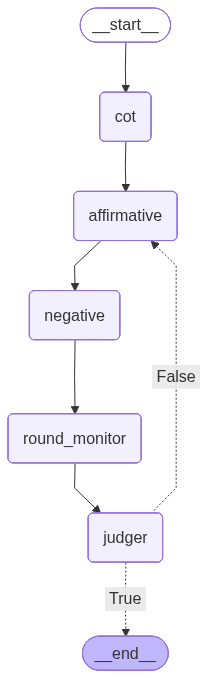

🎭 ディベート大会を開始します...

================================ Human Message =================================
Name: CoT_Assistant

この状況について、ステップバイステップで論点を整理します。

### ステップ1: アラートの発報
- **時刻**: 深夜3時47分
- **検知内容**: 特定の社内PC（192.168.10.44）から外部IP（203.0.113.82）への大量データ送信（4.7 GB）
- **実行中のプロセス**: `sync_agent.exe`（AccountingSaaSの同期プログラム）
- **操作ユーザ**: 経理部の社員（yamada.keiko@example.com）
- **ヒットしたルール**: "1GB以上の外部送信を検知"

### ステップ2: 脅威インテリジェンスでの照合
- **送信先IPの照合結果**:
  - ベンダーA: 問題なし
  - ベンダーB: 問題なし
  - ベンダーC: "2024年9月に情報窃取キャンペーンで観測されたIPを含むサブネット"
- **判定**: Confidence High（3社中1社がヒット）

### ステップ3: EDRでの端末確認
- **デジタル署名**: 有効（AccountingSaaS Inc.発行）
- **親プロセス**: 正規のWindowsサービス（services.exe）
- **実行権限**: SYSTEM権限
- **直近の異常**: なし

### ステップ4: エージェントの自動対応
- **実行した対応**:
  - PCのネットワーク接続を遮断
  - アカウント（yamada.keiko）の一時停止
  - インシデントチケット #2891 を自動起票
- **総合判定**: Confidence 87%

### ステップ5: 翌朝の調査結果
- **yamada.keikoの役割**: 経理部の社員で、月次決算の作業中だった
- **実行中のプログラム**: `sync_agent.exe`は公式バックアッププログラム
- **送信先IPの正体**: 会計SaaSのデータセンターのIP（ホワイトリストへの登録漏れ）


In [12]:
import os
import functools
from typing import Annotated, TypedDict
from google.colab import userdata
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import display, Image

# 1. APIキーの設定
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. モデルの準備 (審判は賢い4o、選手は機敏な4o-mini)
llm_judge = ChatOpenAI(model="gpt-4o", temperature=0)
llm_player = ChatOpenAI(model="gpt-4o-mini", temperature=0.7) # 議論を活性化させるため少し温度を上げます

# 3. 状態(State)の定義
class DebateState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    debate_topic: str
    judged: bool
    round: int

# --- 4. エージェント関数の定義 ---

# 導入エージェント (CoT)
def cot_agent(state: DebateState):
    system_prompt = SystemMessage(content=f"議題「{state['debate_topic']}」について、論点をステップバイステップで整理してください。")
    res = llm_player.invoke([system_prompt])
    message = HumanMessage(content=res.content, name="CoT_Assistant")
    return {"messages": [message]}

# ディベーター関数
def debater(state: DebateState, name: str, position: str):
    system_prompt = SystemMessage(content=(
        f"あなたはディベーターです。議題：{state['debate_topic']}\n"
        f"立ち位置：{position}\n"
        "相手の主張がある場合は、論理的に反論しつつ自分の主張を述べてください。簡潔に！"
    ))
    res = llm_player.invoke([system_prompt] + state["messages"])
    message = HumanMessage(content=res.content, name=name)
    return {"messages": [message]}

# 肯定側と否定側の設定
affirmative_debater = functools.partial(debater, name="Affirmative", position="肯定派。メリットを強調してください。")
negative_debater = functools.partial(debater, name="Negative", position="否定派。リスクやデメリットを強調してください。")

# 審判（Judger）
class JudgeSchema(BaseModel):
    judged: bool = Field(..., description="勝敗がついたかどうか")
    answer: str = Field(..., description="判定結果とその理由")

def judger(state: DebateState):
    system_prompt = SystemMessage(content=(
        f"あなたはディベートの審判です。議題：{state['debate_topic']}\n"
        "これまでの議論を評価し、決着がついたか判断してください。"
    ))
    llm_with_format = llm_judge.with_structured_output(JudgeSchema)
    res = llm_with_format.invoke([system_prompt] + state["messages"])

    messages = []
    if res.judged:
        messages.append(HumanMessage(content=f"【審判の判決】\n{res.answer}", name="Judge"))

    return {"messages": messages, "judged": res.judged}

# ラウンド管理
def round_monitor(state: DebateState, max_round: int):
    new_round = state["round"] + 1
    if new_round >= max_round:
        return {"round": new_round, "messages": [HumanMessage(content="最終ラウンドです。審判は必ず勝敗を決してください。")]}
    return {"round": new_round}

# --- 5. グラフの構築 ---
builder = StateGraph(DebateState)

builder.add_node("cot", cot_agent)
builder.add_node("affirmative", affirmative_debater)
builder.add_node("negative", negative_debater)
builder.add_node("round_monitor", functools.partial(round_monitor, max_round=3))
builder.add_node("judger", judger)

# エッジを繋ぐ
builder.add_edge(START, "cot")
builder.add_edge("cot", "affirmative")
builder.add_edge("affirmative", "negative")
builder.add_edge("negative", "round_monitor")
builder.add_edge("round_monitor", "judger")

# 審判の判定による条件分岐
builder.add_conditional_edges(
    "judger",
    lambda state: state["judged"],
    {True: END, False: "affirmative"}
)

graph = builder.compile()

# --- 6. 実行 ---
display(Image(graph.get_graph().draw_mermaid_png()))

inputs = {
    "messages": [],
    "debate_topic": r"""======================================================================================================================================================================================================
# 問１
## はじめに読んでほしいこと
企業のセキュリティ部門（SOC）では最近、アラートの量が多すぎて人間だけでは対応しきれないため、AIエージェントに検知から対応までを自動で行えるようにしたいと考えています。

この設問では、そのようなAIエージェントが実際に動いた場面のログを読んで、「AIの判断は適切だったか」を考えてもらいます。

## 状況説明
ある会社のSOCに、AIエージェントが導入されて3ヶ月が経ちます。このエージェントは

* 社内ネットワークの通信を常時監視し
* 不審と判断した場合は自動でPCの通信を止めたりアカウントを無効化したりできる
* 対応後にSOCの担当者へメールで通知する

という仕組みで動いています。担当者は対応後に知らされる設計です。

## ログの解読
以下のログは、AIエージェントが深夜に何かを検知してから、翌朝に担当者が調査するまでの記録です。時系列順に並んでいます。各ブロックが「エージェントが何をしたか／調べたか」を示しています。

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 1】 深夜3時47分 ─ SIEMがアラートを発報
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  検知内容 : 社内PC（192.168.10.44）から外部IPへの大量データ送信
  送信先   : 203.0.113.82（社外）
  通信量   : 23分間で4.7 GB（HTTPS）
  実行中の
  プロセス : C:\Program Files\AccountingSaaS\sync_agent.exe
             ↑「AccountingSaaS」というソフトウェアの同期プログラム
  操作ユーザ: yamada.keiko@example.com
  ヒットしたルール   : ""1GB以上の外部送信を検知""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 2】 深夜3時47分 ─ 脅威インテリジェンスで送信先IPを照合
           ※脅威インテリジェンス＝既知の悪性IPや攻撃者情報のデータベース
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  照合対象 : 203.0.113.82
  ベンダーA : 問題なし
  ベンダーB : 問題なし
  ベンダーC : 「2024年9月に情報窃取キャンペーンで観測されたIPを含むサブネット」という記録あり  ← ★ここだけがヒット
  判定     : Confidence High（3社中1社がヒット）

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 3】 深夜3時47分 ─ EDRで端末を確認
           ※EDR＝PCの上で何のプロセスが動いているかを監視するツール
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  プロセスのデジタル署名: 有効（発行元：AccountingSaaS Inc.）
   ↑正規のソフトウェアとして認証されている

  親プロセス  : services.exe（Windowsの正規サービス起動プロセス）
  実行権限    : SYSTEM権限
  直近の異常  : なし

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 4】 深夜3時47分 ─ エージェントが自動対応を実行
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  実行した対応:
    → PC（192.168.10.44）のネットワーク接続を遮断
    → Active Directoryのアカウント yamada.keiko を一時停止
       ↑社内の認証システム。停止するとPC・メール・社内システムすべてにログイン不可
    → インシデントチケット #2891 を自動起票
  総合判定   : Confidence 87%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 5】 翌朝8時30分 ─ 出社したSOCアナリストが調査した結果
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ・yamada.keiko は経理部の社員。前日から月次決算の作業をしていた
  ・sync_agent.exe は会社が契約しているクラウド会計SaaSの公式バックアッププログラムだった
  ・送信先の 203.0.113.82 はその会計SaaSのデータセンターのIPだった
    （社内のホワイトリスト＝許可リストへの登録が漏れていた）
  ・ベンダーCがヒットした理由：2024年9月のレポートに「このIPと同じサブネット（/24）の中に悪性IPがあった」という記述があっただけで、このIPアドレスそのものへの評価ではなかった

・対応の結果：復旧作業に2.5時間かかり、月次決算の提出が4時間遅延した
""",
    "judged": False,
    "round": 0,
}

print("🎭 ディベート大会を開始します...\n")
for event in graph.stream(inputs):
    for value in event.values():
        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()


否定側の意見に、どうするべきだったかを主張してもらうようコードを変更

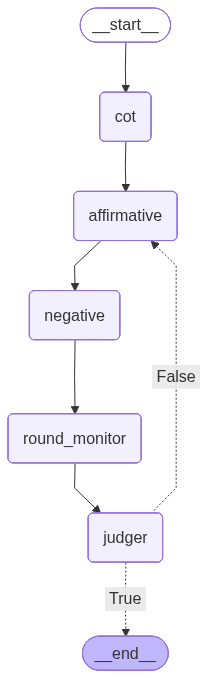

🎭 ディベート大会を開始します...

================================ Human Message =================================
Name: CoT_Assistant

この状況のログを基に、AIエージェントの判断が適切だったかどうかをステップバイステップで整理します。

### ステップ1: アラートの発報
- **内容**: 社内PC（192.168.10.44）から外部IP（203.0.113.82）への大量データ送信が検知されました。
- **通信量**: 23分間で4.7 GBのHTTPS通信。
- **プロセス**: C:\Program Files\AccountingSaaS\sync_agent.exeという正規のソフトウェアが実行中。
- **ユーザ**: yamada.keiko@example.comという経理部の社員が操作。

### ステップ2: 脅威インテリジェンスでの照合
- **照合結果**: 203.0.113.82に対して、ベンダーCが「情報窃取キャンペーンで観測されたIPを含むサブネット」との記録を持っていた。
- **判定**: ConfidenceはHigh（3社中1社がヒット）。

### ステップ3: EDRでの端末確認
- **プロセスの署名**: 有効であり、正規のソフトウェアとして認証されている。
- **親プロセス**: 正規のWindowsサービスであるservices.exe。
- **実行権限**: SYSTEM権限を持つが、直近の異常はなし。

### ステップ4: エージェントの自動対応
- **実行した対応**:
  - PCのネットワーク接続を遮断。
  - Active Directoryのアカウントを一時停止。
  - インシデントチケットを自動起票。
- **総合判定**: Confidenceは87%。

### ステップ5: SOCアナリストの調査結果
- **yamada.keiko**: 経理部の社員で、月次決算作業を行っていた。
- **sync_agent.exe**: 会社が契約しているクラウド会計SaaSの公式バックアッププログラム。
- **送信先のIP**: 203.0.113.82はその会計Saa

In [13]:
import os
import functools
from typing import Annotated, TypedDict
from google.colab import userdata
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import display, Image

# 1. APIキーの設定
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# 2. モデルの準備 (審判は賢い4o、選手は機敏な4o-mini)
llm_judge = ChatOpenAI(model="gpt-4o", temperature=0)
llm_player = ChatOpenAI(model="gpt-4o-mini", temperature=0.7) # 議論を活性化させるため少し温度を上げます

# 3. 状態(State)の定義
class DebateState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    debate_topic: str
    judged: bool
    round: int

# --- 4. エージェント関数の定義 ---

# 導入エージェント (CoT)
def cot_agent(state: DebateState):
    system_prompt = SystemMessage(content=f"議題「{state['debate_topic']}」について、論点をステップバイステップで整理してください。")
    res = llm_player.invoke([system_prompt])
    message = HumanMessage(content=res.content, name="CoT_Assistant")
    return {"messages": [message]}

# ディベーター関数
def debater(state: DebateState, name: str, position: str):
    system_prompt = SystemMessage(content=(
        f"あなたはディベーターです。議題：{state['debate_topic']}\n"
        f"立ち位置：{position}\n"
        "相手の主張がある場合は、論理的に反論しつつ自分の主張を述べてください。簡潔に！"
    ))
    res = llm_player.invoke([system_prompt] + state["messages"])
    message = HumanMessage(content=res.content, name=name)
    return {"messages": [message]}

# 肯定側と否定側の設定
affirmative_debater = functools.partial(debater, name="Affirmative", position="肯定派。メリットを強調してください。")
negative_debater = functools.partial(debater, name="Negative", position="否定派。リスクやデメリットを強調してください。また、どうすれば正しかったかの意見も主張してください")

# 審判（Judger）
class JudgeSchema(BaseModel):
    judged: bool = Field(..., description="勝敗がついたかどうか")
    answer: str = Field(..., description="判定結果とその理由")

def judger(state: DebateState):
    system_prompt = SystemMessage(content=(
        f"あなたはディベートの審判です。議題：{state['debate_topic']}\n"
        "これまでの議論を評価し、決着がついたか判断してください。"
    ))
    llm_with_format = llm_judge.with_structured_output(JudgeSchema)
    res = llm_with_format.invoke([system_prompt] + state["messages"])

    messages = []
    if res.judged:
        messages.append(HumanMessage(content=f"【審判の判決】\n{res.answer}", name="Judge"))

    return {"messages": messages, "judged": res.judged}

# ラウンド管理
def round_monitor(state: DebateState, max_round: int):
    new_round = state["round"] + 1
    if new_round >= max_round:
        return {"round": new_round, "messages": [HumanMessage(content="最終ラウンドです。審判は必ず勝敗を決してください。")]}
    return {"round": new_round}

# --- 5. グラフの構築 ---
builder = StateGraph(DebateState)

builder.add_node("cot", cot_agent)
builder.add_node("affirmative", affirmative_debater)
builder.add_node("negative", negative_debater)
builder.add_node("round_monitor", functools.partial(round_monitor, max_round=3))
builder.add_node("judger", judger)

# エッジを繋ぐ
builder.add_edge(START, "cot")
builder.add_edge("cot", "affirmative")
builder.add_edge("affirmative", "negative")
builder.add_edge("negative", "round_monitor")
builder.add_edge("round_monitor", "judger")

# 審判の判定による条件分岐
builder.add_conditional_edges(
    "judger",
    lambda state: state["judged"],
    {True: END, False: "affirmative"}
)

graph = builder.compile()

# --- 6. 実行 ---
display(Image(graph.get_graph().draw_mermaid_png()))

inputs = {
    "messages": [],
    "debate_topic": r"""======================================================================================================================================================================================================
# 問１
## はじめに読んでほしいこと
企業のセキュリティ部門（SOC）では最近、アラートの量が多すぎて人間だけでは対応しきれないため、AIエージェントに検知から対応までを自動で行えるようにしたいと考えています。

この設問では、そのようなAIエージェントが実際に動いた場面のログを読んで、「AIの判断は適切だったか」を考えてもらいます。

## 状況説明
ある会社のSOCに、AIエージェントが導入されて3ヶ月が経ちます。このエージェントは

* 社内ネットワークの通信を常時監視し
* 不審と判断した場合は自動でPCの通信を止めたりアカウントを無効化したりできる
* 対応後にSOCの担当者へメールで通知する

という仕組みで動いています。担当者は対応後に知らされる設計です。

## ログの解読
以下のログは、AIエージェントが深夜に何かを検知してから、翌朝に担当者が調査するまでの記録です。時系列順に並んでいます。各ブロックが「エージェントが何をしたか／調べたか」を示しています。

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 1】 深夜3時47分 ─ SIEMがアラートを発報
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  検知内容 : 社内PC（192.168.10.44）から外部IPへの大量データ送信
  送信先   : 203.0.113.82（社外）
  通信量   : 23分間で4.7 GB（HTTPS）
  実行中の
  プロセス : C:\Program Files\AccountingSaaS\sync_agent.exe
             ↑「AccountingSaaS」というソフトウェアの同期プログラム
  操作ユーザ: yamada.keiko@example.com
  ヒットしたルール   : ""1GB以上の外部送信を検知""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 2】 深夜3時47分 ─ 脅威インテリジェンスで送信先IPを照合
           ※脅威インテリジェンス＝既知の悪性IPや攻撃者情報のデータベース
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  照合対象 : 203.0.113.82
  ベンダーA : 問題なし
  ベンダーB : 問題なし
  ベンダーC : 「2024年9月に情報窃取キャンペーンで観測されたIPを含むサブネット」という記録あり  ← ★ここだけがヒット
  判定     : Confidence High（3社中1社がヒット）

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 3】 深夜3時47分 ─ EDRで端末を確認
           ※EDR＝PCの上で何のプロセスが動いているかを監視するツール
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  プロセスのデジタル署名: 有効（発行元：AccountingSaaS Inc.）
   ↑正規のソフトウェアとして認証されている

  親プロセス  : services.exe（Windowsの正規サービス起動プロセス）
  実行権限    : SYSTEM権限
  直近の異常  : なし

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 4】 深夜3時47分 ─ エージェントが自動対応を実行
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  実行した対応:
    → PC（192.168.10.44）のネットワーク接続を遮断
    → Active Directoryのアカウント yamada.keiko を一時停止
       ↑社内の認証システム。停止するとPC・メール・社内システムすべてにログイン不可
    → インシデントチケット #2891 を自動起票
  総合判定   : Confidence 87%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
【STEP 5】 翌朝8時30分 ─ 出社したSOCアナリストが調査した結果
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ・yamada.keiko は経理部の社員。前日から月次決算の作業をしていた
  ・sync_agent.exe は会社が契約しているクラウド会計SaaSの公式バックアッププログラムだった
  ・送信先の 203.0.113.82 はその会計SaaSのデータセンターのIPだった
    （社内のホワイトリスト＝許可リストへの登録が漏れていた）
  ・ベンダーCがヒットした理由：2024年9月のレポートに「このIPと同じサブネット（/24）の中に悪性IPがあった」という記述があっただけで、このIPアドレスそのものへの評価ではなかった

・対応の結果：復旧作業に2.5時間かかり、月次決算の提出が4時間遅延した
""",
    "judged": False,
    "round": 0,
}

print("🎭 ディベート大会を開始します...\n")
for event in graph.stream(inputs):
    for value in event.values():
        if "messages" in value and value["messages"]:
            value["messages"][-1].pretty_print()